# 1 -- Carga y Exploracion Inicial del conjunto de datos.--
Importaremos las librerias necesarias y cargaremos  el archivo.

In [1]:
from google.colab import files # importar csv en colab
uploaded = files.upload() # Cargar archivo local
# Librerias estándar para analisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
pd.set_option('display.max_columns', None) # Ver todas las columnas
print('✅ Librerías cargadas correctamente')

Saving greenmart_customers_products.csv to greenmart_customers_products (1).csv
✅ Librerías cargadas correctamente


Cargar el CSV

In [2]:
from google.colab import files


df = pd.read_csv('greenmart_customers_products.csv')

print(f'📦 Dataset cargado : {df.shape[0]} filas × {df.shape[1]} columnas ')

📦 Dataset cargado : 10400 filas × 11 columnas 


Primer vista del Dataset

In [3]:
# --- Ver las primeras y las ultimas filas ---

print('-- Primeras 5 filas --')
display(df.head())

print('\n-- Últimas 5 filas --')
display(df.tail())

-- Primeras 5 filas --


,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
0,1,Ronald Miller,63.0,Wilsonstad,141,Granola,Vegetable,2024-10-21,1.0,13.33,13.33
1,2,Eric White,26.0,North Brianside,172,Organic Apples,Vegetable,2024-08-15,2.0,1.04,2.08
2,3,Joseph Wagner,59.0,Lake Derek,186,Granola,Dairy,2024-07-16,1.0,15.33,15.33
3,4,Elizabeth House,43.0,Cindyborough,110,Granola,Snack,2024-09-18,1.0,10.55,10.55
4,5,Shawn Warner,56.0,North Hannah,147,Fresh Milk,Snack,2024-10-09,1.0,12.25,12.25



-- Últimas 5 filas --


,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
10395,9745,Jeffrey Cantrell,28.0,Port Brenda,191,Kale,Organic,2024-05-16,1.0,15.82,15.82
10396,9251,Annette Flores,21.0,North Johnview,162,Almond Butter,Organic,2024-04-11,2.0,9.46,18.92
10397,8525,Christopher Ray,51.0,Reedville,186,Tofu,Vegetable,2024-04-01,2.0,6.51,13.02
10398,4929,Laura Ruiz,18.0,Leeview,125,Organic Apples,Organic,2024-09-27,2.0,2.03,4.06
10399,3044,Michael Johnson,40.0,South Williamville,148,Kale,Snack,2024-03-23,3.0,2.90,8.70


Tipos de datos y estructura

In [4]:
print('--Tipos de datos por column --')
print(df.dtypes)

print('\n -- Info general --')
df.info()

--Tipos de datos por column --
customer_id            int64
customer_name         object
age                  float64
city                  object
product_id             int64
product_name          object
category              object
purchase_date         object
purchase_quantity    float64
price_per_unit       float64
total_spent          float64
dtype: object

 -- Info general --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        10400 non-null  int64  
 1   customer_name      9678 non-null   object 
 2   age                9678 non-null   float64
 3   city               9678 non-null   object 
 4   product_id         10400 non-null  int64  
 5   product_name       10400 non-null  object 
 6   category           10400 non-null  object 
 7   purchase_date      9678 non-null   object 
 8   purchase_quantity  96

Valores faltantes


-- Valores faltantes por columna --


,Valores faltantes,Porcentaje (%)
customer_name,722,6.94
age,722,6.94
city,722,6.94
purchase_date,722,6.94
purchase_quantity,708,6.81
total_spent,708,6.81


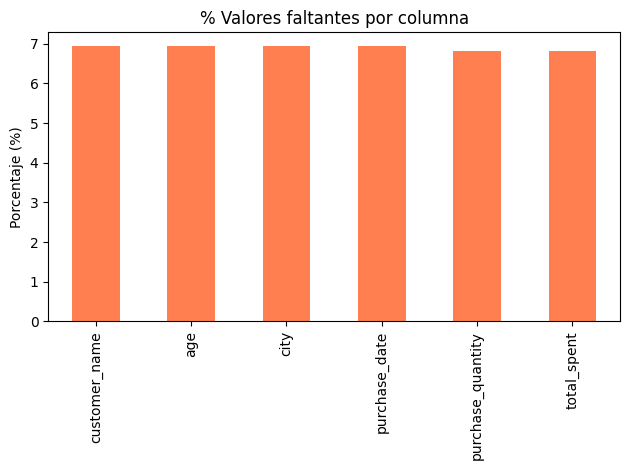

In [5]:
# --Análisis de valores faltantes--
missing = df.isnull().sum() # Contar valores faltantes
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores faltantes': missing,
    'Porcentaje (%)': missing_pct
}).sort_values('Porcentaje (%)', ascending=False)

print('-- Valores faltantes por columna --')
display(missing_df[missing_df['Valores faltantes'] > 0])

# Visualizacion profesional
if missing_df['Valores faltantes'].sum() > 0:
  missing_df[missing_df['Valores faltantes'] > 0]['Porcentaje (%)'].plot(
      kind='bar', color='coral', title='% Valores faltantes por columna'
  )
  plt.ylabel('Porcentaje (%)')
  plt.tight_layout()
  plt.show()
else:
  print('✅  No se encontraron valores faltantes')


Filas duplicadas



In [6]:
# -- Detención de duplicados
n_duplicados = df.duplicated().sum()
print(f'🔁 Filas duplicadas encontradas: {n_duplicados}')

if n_duplicados > 0:
  print('\nEjemplo de filas duplicadas:')
  display(df[df.duplicated(keep=False)].head(10))

🔁 Filas duplicadas encontradas: 367

Ejemplo de filas duplicadas:


,customer_id,customer_name,age,city,product_id,product_name,category,purchase_date,purchase_quantity,price_per_unit,total_spent
17,18,Megan Charles,34.0,Richardville,140,Organic Apples,Dairy,2024-05-25,2.0,8.12,16.24
30,31,Stephanie Allen,50.0,South Andrew,183,Almond Butter,Snack,2024-01-10,1.0,12.90,12.90
45,46,Allen Parks,35.0,North Alexis,124,Almond Butter,Snack,2024-02-23,2.0,3.11,6.22
70,71,Shawn Khan,34.0,Aprilview,129,Fresh Milk,Vegetable,2024-05-02,4.0,16.00,64.00
109,110,Thomas Shaw,35.0,Calderonside,150,Almond Butter,Vegetable,2024-04-18,3.0,15.08,45.24
213,214,Lacey Larson,27.0,Patrickmouth,163,Organic Apples,Organic,2024-04-19,1.0,13.47,13.47
215,216,Elizabeth Nelson,73.0,East Robert,122,Almond Butter,Snack,2024-03-31,2.0,14.64,29.28
223,224,Steven Allen,57.0,East Taramouth,123,Fresh Milk,Organic,2024-04-20,4.0,11.43,45.72
240,241,Rebecca Clarke,59.0,North Kara,144,Organic Apples,Dairy,2024-06-19,2.0,5.83,11.66
248,249,Julie Li,44.0,Torresside,199,Granola,Dairy,2024-03-23,1.0,7.16,7.16


Se encontraron 367 filas duplicadas (3,5%). Serán eliminadas antes de cualquier transformación
para no procesar registros que serán descartados.

Estadisticas descriptivas

In [7]:
# -- Estadisticas descriptivas (columnas númericas) --
print('--Estadisticas descriptivas--')
display(df.describe())

--Estadisticas descriptivas--


,customer_id,age,product_id,purchase_quantity,price_per_unit,total_spent
count,10400.000000,9678.000000,10400.000000,9692.000000,10400.000000,9692.000000
mean,4998.865865,48.408039,149.807019,4.044057,13.303007,57.339865
std,2885.673499,17.920275,28.743019,15.512675,30.721385,793.619525
min,1.000000,18.000000,100.000000,1.000000,1.000000,1.000000
25%,2503.000000,33.000000,125.000000,1.000000,5.910000,11.197500
50%,4995.500000,48.000000,150.000000,3.000000,10.730000,20.920000
75%,7492.250000,64.000000,175.000000,4.000000,15.500000,38.700000
max,10000.000000,79.000000,199.000000,199.000000,499.350000,75475.350000


Se detectan posibles outliers: purchase_quantity llega a 199 (mediana: 3),
total_spent alcanza \$75.475 con una media de $57. Serán analizados con IQR en el Paso 5.

# **Sintesis**

El dataset contiene 10.400 registros y 11 columnas. Se detectaron 367 filas duplicadas exactas (3,5%) que serán eliminadas antes del análisis.
Los valores faltantes siguen un patrón estructural: cuatro columnas vinculadas al cliente (nombre, edad, ciudad y fecha de compra) presentan exactamente 722 nulos cada una, lo que sugiere registros donde la información del cliente no fue capturada en el momento de la transacción. De forma independiente, las columnas de compra (cantidad y gasto total) registran 708 nulos, indicando transacciones sin detalle de monto.

Las estadísticas descriptivas revelan la presencia de posibles valores atípicos en variables clave. La variable `purchase_quantity` alcanza un máximo de 199 unidades frente a una mediana de 3. Asimismo, `price_per_unit` registra un valor máximo de 499,35. Por su parte, `total_spent` presenta un máximo de 75.475, una media de 57 y una desviación estándar de 793.

Los tipos de datos requieren corrección: purchase_date está almacenada como texto (object) y deberá convertirse a formato fecha, y los identificadores customer_id y product_id se convertirán a cadena de texto para evitar operaciones aritméticas accidentales.

# Paso 2 - Perfilado de calidad de datos-

In [8]:
# ── Perfil completo de calidad de datos ───────────────────────────────────
def perfil_calidad(df):
    """
    Genera un reporte wápido de calidad de datos para un DataFrame.
    Evalúa dimensiones, duplicados, nulos, tipos de datos y valores ilógicos.
    """
    print("=" * 60)
    print("REPORTE DE CALIDAD DE DATOS")
    print("=" * 60)

    # 1. Tamaño de dataset
    print(f"\n📐 Forma del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")

    # 2. Conteo de Duplicados
    n_dup = df.duplicated().sum()
    print(f"\n🔁 Filas duplicadas exactas: {n_dup} ({n_dup/len(df)*100:.1f}%)")

    # 3. Valores faltantes
    print("\n🕳️  Valores faltantes:")
    missing = df.isnull().sum()
    for col, val in missing[missing > 0].items():
        print(f"   • {col}: {val} ({val/len(df)*100:.1f}%)")
    if missing.sum() == 0:
        print("   ✅ Ninguno")

    # 4. Tipos de datos
    print("\n🏷️  Tipos de datos:")
    for col, dtype in df.dtypes.items():
        print(f"   • {col}: {dtype}")

    # 5. Columnas numéricas clave
    num_cols = ['age', 'purchase_quantity', 'price_per_unit', 'total_spent']
    num_existentes = [c for c in num_cols if c in df.columns]
    if num_existentes:
        print("\n📊 Estadísticas de columnas numéricas clave:")
        display(df[num_existentes].describe())

    # 6. Valores negativos o cero sospechosos
    print("\n⚠️  Valores <= 0 en columnas numéricas:")
    for col in num_existentes:
        if df[col].dtype in ['float64', 'int64']:
            n = (df[col] <= 0).sum()
            if n > 0:
                print(f"   • {col}: {n} valores ≤ 0")

    print("\n" + "=" * 60)

perfil_calidad(df)

REPORTE DE CALIDAD DE DATOS

📐 Forma del dataset: 10400 filas × 11 columnas

🔁 Filas duplicadas exactas: 367 (3.5%)

🕳️  Valores faltantes:
   • customer_name: 722 (6.9%)
   • age: 722 (6.9%)
   • city: 722 (6.9%)
   • purchase_date: 722 (6.9%)
   • purchase_quantity: 708 (6.8%)
   • total_spent: 708 (6.8%)

🏷️  Tipos de datos:
   • customer_id: int64
   • customer_name: object
   • age: float64
   • city: object
   • product_id: int64
   • product_name: object
   • category: object
   • purchase_date: object
   • purchase_quantity: float64
   • price_per_unit: float64
   • total_spent: float64

📊 Estadísticas de columnas numéricas clave:


,age,purchase_quantity,price_per_unit,total_spent
count,9678.000000,9692.000000,10400.000000,9692.000000
mean,48.408039,4.044057,13.303007,57.339865
std,17.920275,15.512675,30.721385,793.619525
min,18.000000,1.000000,1.000000,1.000000
25%,33.000000,1.000000,5.910000,11.197500
50%,48.000000,3.000000,10.730000,20.920000
75%,64.000000,4.000000,15.500000,38.700000
max,79.000000,199.000000,499.350000,75475.350000



⚠️  Valores <= 0 en columnas numéricas:



# Problemas especifico: Fechas

In [9]:
# -- Diagnostico de purchase_date --
print(' -- Muestra de purchase_date --')
print(df['purchase_date'].value_counts(dropna=False).head(10))

# Intentar parsear fechas y detectar las que fallan
fechas_parseadas = pd.to_datetime(df['purchase_date'], errors='coerce')
n_invalidas = fechas_parseadas.isnull().sum()
n_originales_nulas = df['purchase_date'].isnull().sum()
n_formato_roto = n_invalidas - n_originales_nulas

print(f'\n📅 Fechas nulas originalmente: {n_originales_nulas}')
print(f'📅 Fechas con formato invalido (no parseables): {n_formato_roto}')

 -- Muestra de purchase_date --
purchase_date
NaN           722
2024-10-07     49
2024-01-29     45
2024-02-27     45
2024-04-09     45
2024-09-01     44
2024-09-14     44
2024-03-16     44
2024-04-25     43
2024-01-14     43
Name: count, dtype: int64

📅 Fechas nulas originalmente: 722
📅 Fechas con formato invalido (no parseables): 0


# Problema específico: Inconsistencias de texto


In [10]:
# -- Diagnóstico de campos categóricos --
cat_cols = ['customer_name', 'city', 'product_name', 'product_category']
cat_existentes = [c for c in cat_cols if c in df.columns]

for col in cat_existentes:
  valores = df[col].dropna().unique()
  print(f'\n-- {col} ({len(valores)} valores únicos) --')
  # Detectar incosistencias de capitalización
  lower_vals = df[col].dropna().str.lower().unique()
  if len(lower_vals) < len(valores):
    print(f' ⚠️ Posibles duplicados por capitalización: {len(valores) - len(lower_vals)} casos')
  print(f'  Muestra: {list(valores[:8])}')


-- customer_name (8753 valores únicos) --
  Muestra: ['Ronald Miller', 'Eric White', 'Joseph Wagner', 'Elizabeth House', 'Shawn Warner', 'Benjamin Neal', 'Danielle Hayden', 'William Lee']

-- city (7294 valores únicos) --
  Muestra: ['Wilsonstad', 'North Brianside', 'Lake Derek', 'Cindyborough', 'North Hannah', 'Lake Nicholasburgh', 'South Meganborough', 'Ericabury']

-- product_name (12 valores únicos) --
 ⚠️ Posibles duplicados por capitalización: 6 casos
  Muestra: ['Granola', 'Organic Apples', 'Fresh Milk', 'Kale', 'Tofu', 'Almond Butter', 'TOFU', 'KALE']


# Paso 3 Estrategias de limpieza

1. Duplicados        → primero, para no limpiar filas que se van a borrar
2. Tipos de datos    → antes de imputar, necesitás tipos correctos
3. Nulos             → imputar sobre datos ya tipados
4. Texto             → normalizar capitalización
5. Validar totales   → sobre datos ya limpios
6. Flags de outliers → último, sobre el dataset final

#🧹 Paso 4 — Limpieza

In [11]:
# -- Guardar forma original para comparar al final --
df_original_shape = df.shape
df_clean = df.copy()

# -- Eliminar duplicados exactos --
n_antes = len(df_clean)

df_clean = df_clean.drop_duplicates()

n_despues = len(df_clean)

duplicados = n_antes - n_despues
porcentaje = (duplicados / n_antes) * 100

print(f'🔁 Duplicados eliminados: {duplicados}')
print(f'📊 Porcentaje eliminado: {porcentaje:.2f}%')
print(f'📋 Filas antes: {n_antes} → después: {n_despues}')

🔁 Duplicados eliminados: 367
📊 Porcentaje eliminado: 3.53%
📋 Filas antes: 10400 → después: 10033


# Corregir tipos de datos

In [12]:
# ── Conversión de tipos ────────────────────────────────────────────────────

# Fechas
df_clean['purchase_date'] = pd.to_datetime(df_clean['purchase_date'], errors='coerce')
print(f"📅 purchase_date convertida. Nulas resultantes: {df_clean['purchase_date'].isnull().sum()}")

# Numéricos (por si vienen como strings)
for col in ['age', 'purchase_quantity', 'price_per_unit', 'total_spent']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        print(f"🔢 {col} → numérico. Nulos: {df_clean[col].isnull().sum()}")

# IDs como string estable (no numérico, evita operaciones aritméticas accidentales)
for col in ['customer_id', 'product_id']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

📅 purchase_date convertida. Nulas resultantes: 700
🔢 age → numérico. Nulos: 700
🔢 purchase_quantity → numérico. Nulos: 686
🔢 price_per_unit → numérico. Nulos: 0
🔢 total_spent → numérico. Nulos: 686


# Manejar valores faltantes


In [13]:
# ── Imputación y manejo de nulos ──────────────────────────────────────────

# Age: imputar con mediana por ciudad (si hay ciudad), sino mediana global
if 'city' in df_clean.columns:
    df_clean['age'] = df_clean.groupby('city')['age'].transform(
        lambda x: x.fillna(x.median())
    )
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
print(f"👤 age nulos restantes: {df_clean['age'].isnull().sum()}")

# City: marcar como Unknown
df_clean['city'] = df_clean['city'].fillna('Unknown')

# Customer_name: si es nulo, marcar como 'Unknow Customer'
df_clean['customer_name'] = df_clean['customer_name'].fillna('Unknown Customer')
print(f"👤 customer_name nulos restantes: {df_clean['customer_name'].isnull().sum()}")

# Filas sin quantity o price → no podemos recalcular total, las marcamos
mask_sin_datos = df_clean['purchase_quantity'].isnull() | df_clean['price_per_unit'].isnull()
print(f"⚠️  Filas sin quantity o price: {mask_sin_datos.sum()} (se retendrán marcadas)")

print(f"\n✅ Nulos restantes por columna:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

👤 age nulos restantes: 0
👤 customer_name nulos restantes: 0
⚠️  Filas sin quantity o price: 686 (se retendrán marcadas)

✅ Nulos restantes por columna:
purchase_date        700
purchase_quantity    686
total_spent          686
dtype: int64


# Normalizar Texto


In [14]:
# ── Normalización de campos de texto ──────────────────────────────────────
text_cols = ['customer_name', 'city', 'product_name', 'product_category']

for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = (df_clean[col]
                         .astype(str)
                         .str.strip()           # quita espacios extra
                         .str.title()           # Title Case consistente
                         .replace({'Nan' : np.nan}))  # restaurar NaN reales

print("✅ Campos de texto normalizados")

✅ Campos de texto normalizados


Mejora la consistencia de las categorías


# ✔️ Paso 5 — Validación

In [15]:
# ── Validación: total_spent = purchase_quantity * price_per_unit ──────────
TOLERANCIA = 0.02  # 2 centavos de tolerancia por redondeo

df_clean['total_calculado'] = (
    df_clean['purchase_quantity'] * df_clean['price_per_unit']
).round(2)

diferencia = (df_clean['total_spent'] - df_clean['total_calculado']).abs()
mask_error = diferencia > TOLERANCIA

n_errores = mask_error.sum()
print(f"⚠️  Filas con total_spent incorrecto: {n_errores}")

# Corregir con el valor calculado
df_clean.loc[mask_error, 'total_spent'] = df_clean.loc[mask_error, 'total_calculado']
df_clean.drop(columns='total_calculado', inplace=True)

print("✅ total_spent corregido donde correspondía")

⚠️  Filas con total_spent incorrecto: 0
✅ total_spent corregido donde correspondía


La variable total_spent es consistente con purchase_quantity y price_per_unit en todos los registros válidos.

# Detección de outliers (IQR)


In [16]:
# ── Detección de outliers con método IQR ─────────────────────────────────
def detectar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    print(f"   • {col}: {mask.sum()} outliers (rango válido: [{lower:.2f}, {upper:.2f}])")
    return mask

print("🔎 Outliers detectados (método IQR, marcados como flag):")
for col in ['age', 'purchase_quantity', 'price_per_unit', 'total_spent']:
    if col in df_clean.columns:
        flag_col = f'{col}_outlier_flag'
        df_clean[flag_col] = detectar_outliers_iqr(df_clean, col).astype(int)

🔎 Outliers detectados (método IQR, marcados como flag):
   • age: 0 outliers (rango válido: [-9.50, 106.50])
   • purchase_quantity: 100 outliers (rango válido: [-3.50, 8.50])
   • price_per_unit: 100 outliers (rango válido: [-8.52, 29.96])
   • total_spent: 194 outliers (rango válido: [-30.09, 80.17])


# Exportar CSV limpio

In [17]:
# -- Exportación del CSV limpio --
output_path = 'greenmart_customers_products_clean.csv'
df_clean.to_csv(output_path, index=False)

# Verificación: recargar y confirmar integridad
df_verificacion = pd.read_csv(output_path)
assert df_verificacion.shape == df_clean.shape, "❌ Error: formas no coinciden"

print(f"✅ CSV exportado: {output_path}")
print(f"   Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}")
print(f"   Reducción vs original: {df_original_shape[0] - df_clean.shape[0]} filas eliminadas")
print(f"\n── Tipos de datos finales ──")
print(df_clean.dtypes)
print(f"\n── Nulos finales ──")
print(df_clean.isnull().sum())

✅ CSV exportado: greenmart_customers_products_clean.csv
   Filas: 10033 | Columnas: 15
   Reducción vs original: 367 filas eliminadas

── Tipos de datos finales ──
customer_id                               object
customer_name                             object
age                                      float64
city                                      object
product_id                                object
product_name                              object
category                                  object
purchase_date                     datetime64[ns]
purchase_quantity                        float64
price_per_unit                           float64
total_spent                              float64
age_outlier_flag                           int64
purchase_quantity_outlier_flag             int64
price_per_unit_outlier_flag                int64
total_spent_outlier_flag                   int64
dtype: object

── Nulos finales ──
customer_id                         0
customer_name               

Validacion final

# Descargar el csv limpio


In [18]:
from google.colab import files

files.download('greenmart_customers_products_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>